# Music as a Sentiment Barometer
## Notebook 2 — EDA & Visualization

**Goal:** Explore the data and build the hero chart — a 60-year timeline showing how music audio features track alongside economic conditions and consumer sentiment.

**Outputs:**
- `hero_chart.png` — the main shareable figure for GitHub/LinkedIn
- `correlation_heatmap.png` — which audio features correlate with which economic variables
- `recession_pop_validation.png` — does danceability spike during recessions?
- `feature_trends.png` — how all 11 audio features evolved over 60 years

In [20]:
# ── IMPORTS ───────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 150,
})

print('Imports successful!')

Imports successful!


In [21]:
# ── LOAD FINAL DATASETS ───────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

full = pd.read_csv('/content/drive/MyDrive/side_proj/final_dataset_full.csv')
sent = pd.read_csv('/content/drive/MyDrive/side_proj/final_dataset_sentiment.csv')

# Parse dates
full['date'] = pd.to_datetime(full['date'])
sent['date'] = pd.to_datetime(sent['date'])

# Drop rows where misery_index is NaN (first 12 months — inflation needs 12mo lag)
full_clean = full.dropna(subset=['misery_index']).copy()
sent_clean = sent.dropna(subset=['misery_index', 'michigan_sentiment']).copy()

print(f'Full dataset     : {len(full_clean):,} months ({full_clean.date.min().year}–{full_clean.date.max().year})')
print(f'Sentiment dataset: {len(sent_clean):,} months ({sent_clean.date.min().year}–{sent_clean.date.max().year})')
print(f'\nColumns: {list(full_clean.columns)}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Full dataset     : 787 months (1959–2024)
Sentiment dataset: 787 months (1959–2024)

Columns: ['year_month', 'danceability', 'energy', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'date', 'unemployment', 'cpi', 'gdp_growth', 'michigan_sentiment', 'conf_board_sentiment', 'recession', 'inflation', 'misery_index', 'year']


---
## Chart 1 — The Hero Chart

**60 years of economy, sentiment, and music on one timeline.**

So, does music move with the economy?

Three panels sharing the same x-axis:
1. **Valence** (musical happiness) — green
2. **Okun Misery Index** (unemployment + inflation) — red
3. **Michigan Consumer Sentiment** — blue

NBER recession bands are shaded in grey across all panels, sourced directly from the `USREC` series pulled from FRED — representing every official US recession from 1958 to 2024.

The vertical annotations mark key cultural reference points where upbeat, dance-driven genres historically surged in popularity. These labels are placed at approximate dates based on prior literature — specifically Larson (2022), Georgia Tech (2024), and St Andrews (2026) — rather than algorithmically derived from the dataset:

| Era | Approximate Date | Context |
|---|---|---|
| **Disco** | 1976 | Rose during the 1973–75 recession; carefree funk and syncopated rhythms as economic escape |
| **House Music** | 1982 | Emerged in Chicago during the 1981–82 recession; early electronic dance as underground catharsis |
| **Lady Gaga / Kesha era** | 2009 | Defined the sonic mood of the Great Recession; high-BPM club anthems dominated the charts |
| **Lockdown Pop** | 2020 | Mid-COVID period; upbeat, nostalgic, and danceable tracks surged on streaming platforms |
| **Brat** | 2024 | Charli XCX's *Brat* and the broader hyperpop / recession pop revival amid post-COVID economic anxiety |

The hero chart is not about discovering when recessions happened — it is about seeing whether music, hard economic data, and consumer perception **move together**, and which of the two economic layers tracks music more closely. The recession bands serve as the reference frame; the story is in how the three lines behave relative to them.

In [23]:
# Load recession indicator directly from what we already pulled
recession = full_clean[['date', 'recession']].dropna()

def add_recession_bands(ax):
    in_recession = False
    start = None
    for _, row in full_clean.iterrows():
        if row['recession'] == 1 and not in_recession:
            start = row['date']
            in_recession = True
        elif row['recession'] == 0 and in_recession:
            ax.axvspan(start, row['date'], alpha=0.15, color='grey', zorder=0)
            in_recession = False

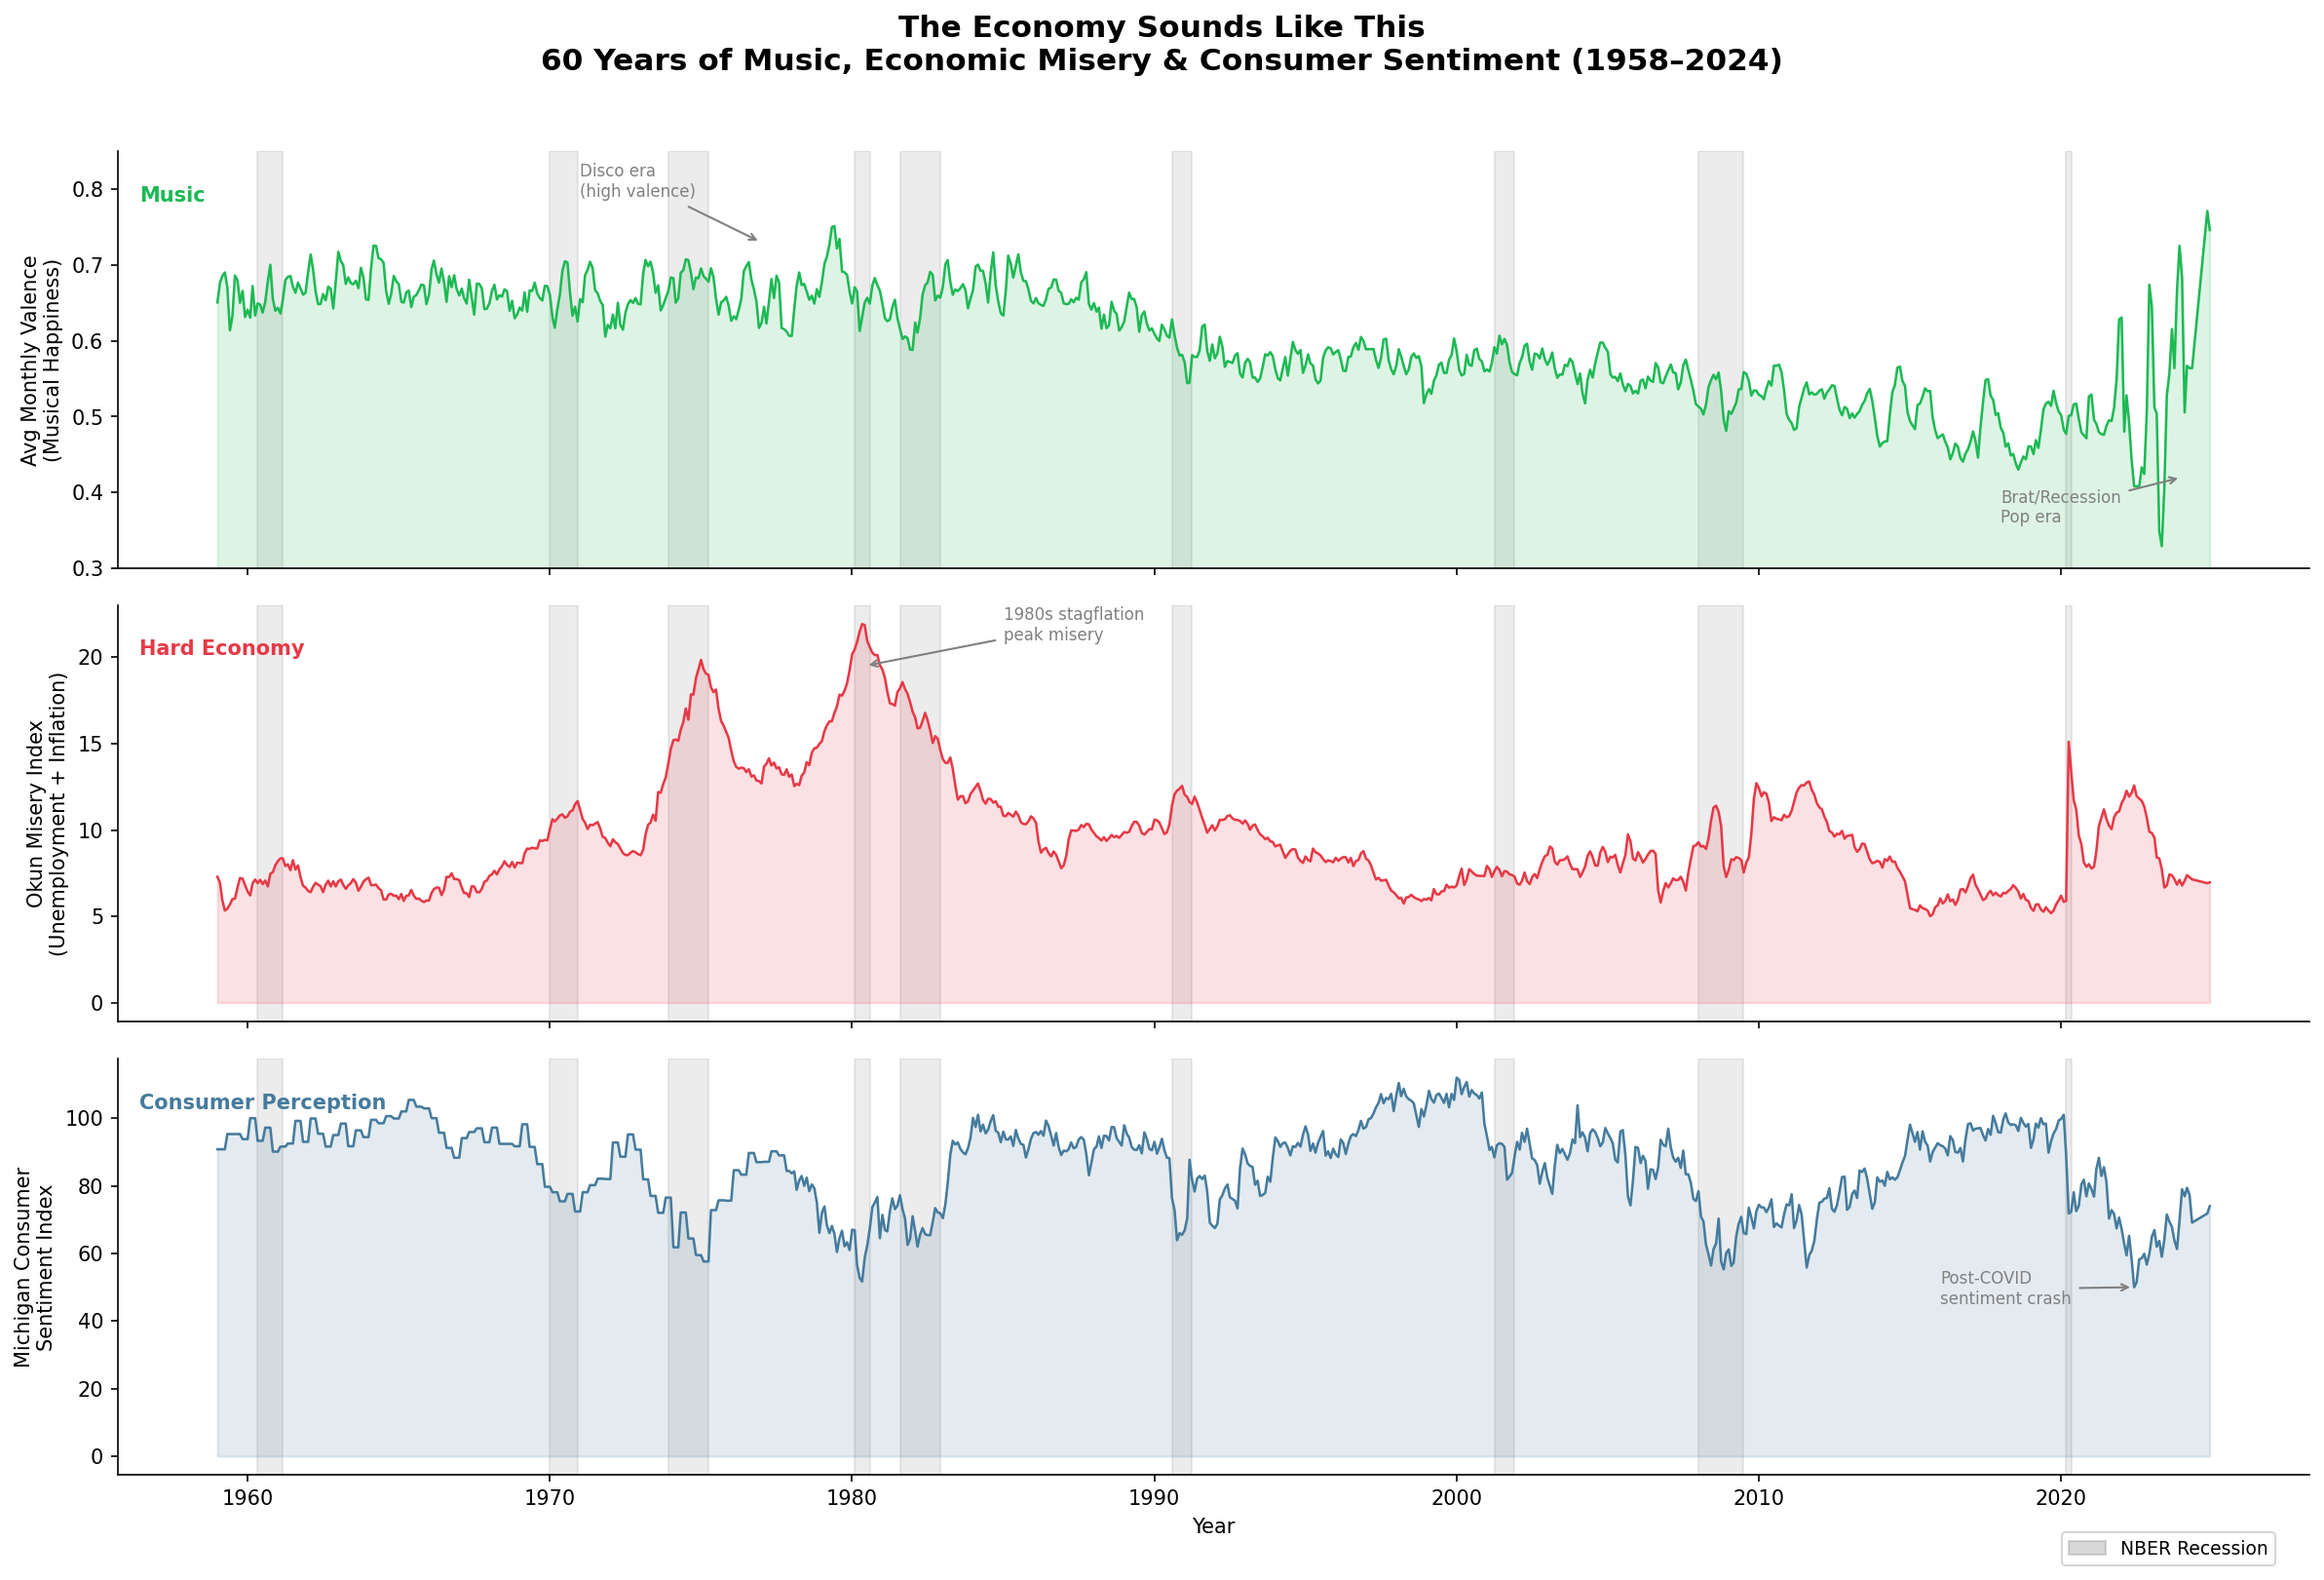

Saved: hero_chart.png


In [24]:
# ── HERO CHART ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 11), sharex=True)
fig.suptitle(
    'The Economy Sounds Like This\n'
    '60 Years of Music, Economic Misery & Consumer Sentiment (1958–2024)',
    fontsize=15, fontweight='bold', y=0.98
)

# ── Panel 1: Valence ──────────────────────────────────────────────────────────
ax1 = axes[0]
ax1.plot(full_clean['date'], full_clean['valence'],
         color='#1DB954', linewidth=1.2, zorder=2)
ax1.fill_between(full_clean['date'], full_clean['valence'],
                  alpha=0.15, color='#1DB954')
add_recession_bands(ax1)
ax1.set_ylabel('Avg Monthly Valence\n(Musical Happiness)', fontsize=10)
ax1.set_ylim(0.3, 0.85)
ax1.text(0.01, 0.88, 'Music', transform=ax1.transAxes,
         fontsize=10, color='#1DB954', fontweight='bold')

# Annotate a few interesting music moments
ax1.annotate('Disco era\n(high valence)', xy=(pd.to_datetime('1977-01-01'), 0.73),
             xytext=(pd.to_datetime('1971-01-01'), 0.79),
             arrowprops=dict(arrowstyle='->', color='grey'),
             fontsize=8, color='grey')
ax1.annotate('Brat/Recession\nPop era', xy=(pd.to_datetime('2024-01-01'), 0.42),
             xytext=(pd.to_datetime('2018-01-01'), 0.36),
             arrowprops=dict(arrowstyle='->', color='grey'),
             fontsize=8, color='grey')

# ── Panel 2: Misery Index ─────────────────────────────────────────────────────
ax2 = axes[1]
ax2.plot(full_clean['date'], full_clean['misery_index'],
         color='#E63946', linewidth=1.2, zorder=2)
ax2.fill_between(full_clean['date'], full_clean['misery_index'],
                  alpha=0.15, color='#E63946')
add_recession_bands(ax2)
ax2.set_ylabel('Okun Misery Index\n(Unemployment + Inflation)', fontsize=10)
ax2.text(0.01, 0.88, 'Hard Economy', transform=ax2.transAxes,
         fontsize=10, color='#E63946', fontweight='bold')
ax2.annotate('1980s stagflation\npeak misery', xy=(pd.to_datetime('1980-06-01'), 19.5),
             xytext=(pd.to_datetime('1985-01-01'), 21),
             arrowprops=dict(arrowstyle='->', color='grey'),
             fontsize=8, color='grey')

# ── Panel 3: Michigan Sentiment ───────────────────────────────────────────────
ax3 = axes[2]
ax3.plot(sent_clean['date'], sent_clean['michigan_sentiment'],
         color='#457B9D', linewidth=1.2, zorder=2)
ax3.fill_between(sent_clean['date'], sent_clean['michigan_sentiment'],
                  alpha=0.15, color='#457B9D')
add_recession_bands(ax3)
ax3.set_ylabel('Michigan Consumer\nSentiment Index', fontsize=10)
ax3.set_xlabel('Year', fontsize=10)
ax3.text(0.01, 0.88, 'Consumer Perception', transform=ax3.transAxes,
         fontsize=10, color='#457B9D', fontweight='bold')
ax3.annotate('Post-COVID\nsentiment crash', xy=(pd.to_datetime('2022-06-01'), 50),
             xytext=(pd.to_datetime('2016-01-01'), 45),
             arrowprops=dict(arrowstyle='->', color='grey'),
             fontsize=8, color='grey')

# ── Legend for recession bands ────────────────────────────────────────────────
recession_patch = mpatches.Patch(color='grey', alpha=0.3, label='NBER Recession')
fig.legend(handles=[recession_patch], loc='lower right',
           bbox_to_anchor=(0.98, 0.01), fontsize=9)

plt.tight_layout(rect=[0, 0.02, 1, 0.96])
plt.savefig('hero_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: hero_chart.png')

## Short Summary

The 60-year timeline reveals that musical valence has declined steadily since the 1960s while danceability has gradually risen — a divergence that accelerates noticeably around economic stress periods.


>Visually, the Michigan Consumer Sentiment line tracks the shape of the valence >line more closely than the Misery Index does, offering an early visual >suggestion that how people feel about the economy may be a stronger driver of >music preference than what the economy actually measures.

---
## Chart 2 — Recession Pop Validation
**Does danceability actually spike during recessions?**

To further examine our hypothesis (dance pop spikes in recessions), we compare the **Dancebility** with **Valance** on the same axes.

This directly tests the core recession pop thesis — comparing danceability and valence before, during, and after each major recession.

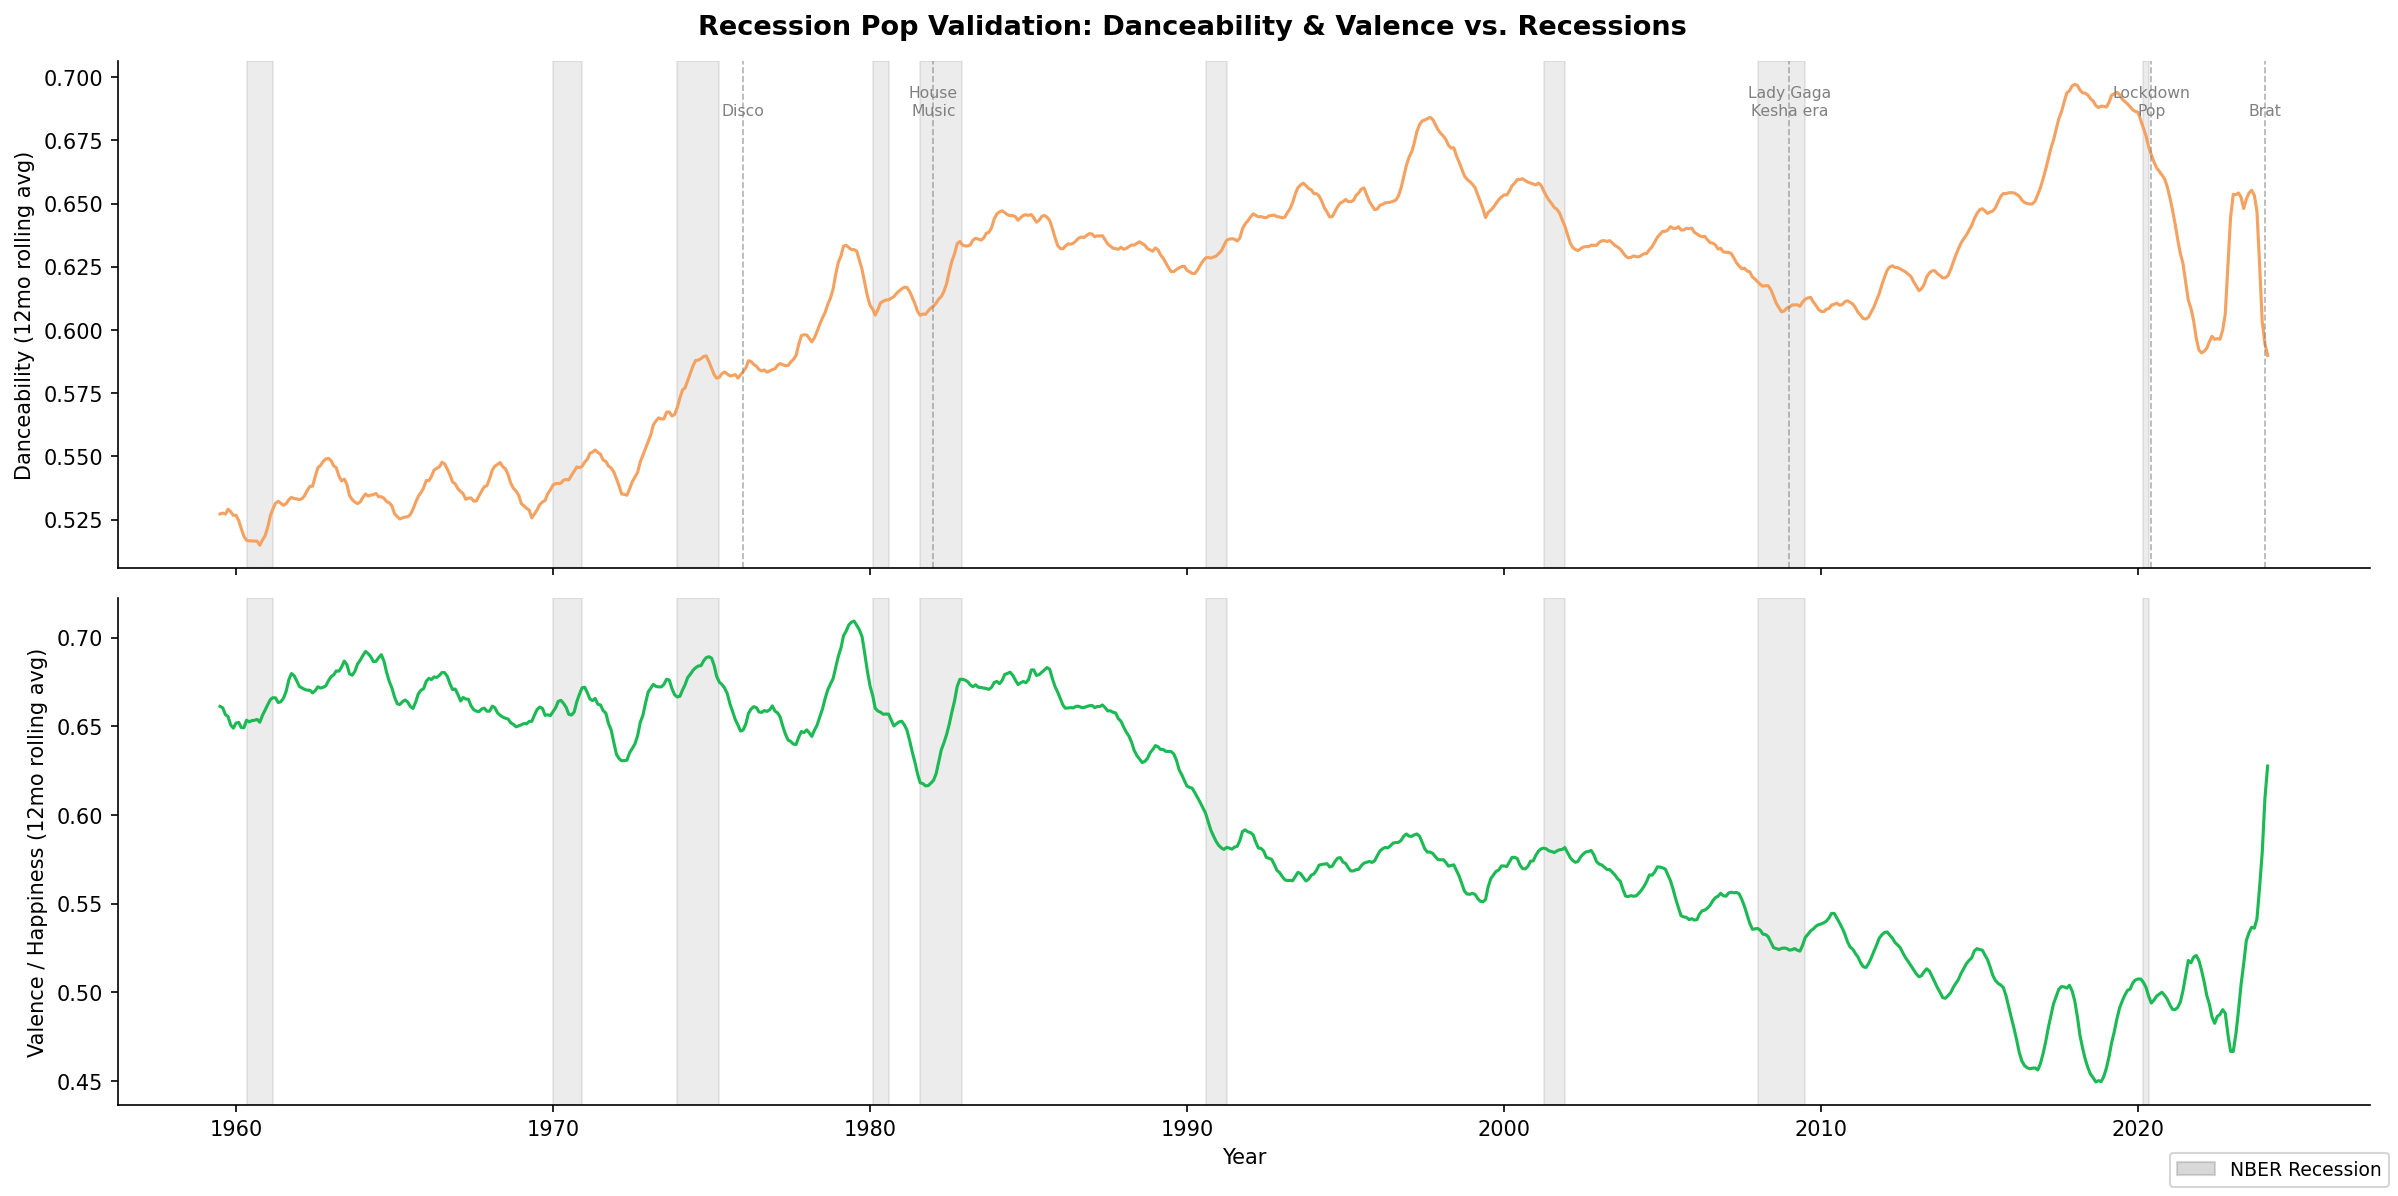

Saved: recession_pop_validation.png


In [25]:
# ── RECESSION POP VALIDATION ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
fig.suptitle('Recession Pop Validation: Danceability & Valence vs. Recessions',
             fontsize=13, fontweight='bold')

# Rolling 12-month average to smooth noise
full_clean = full_clean.sort_values('date')
full_clean['dance_roll'] = full_clean['danceability'].rolling(12, center=True).mean()
full_clean['valence_roll'] = full_clean['valence'].rolling(12, center=True).mean()

for ax, col, color, label in [
    (axes[0], 'dance_roll', '#F4A261', 'Danceability (12mo rolling avg)'),
    (axes[1], 'valence_roll', '#1DB954', 'Valence / Happiness (12mo rolling avg)'),
]:
    ax.plot(full_clean['date'], full_clean[col], color=color, linewidth=1.5)
    add_recession_bands(ax)
    ax.set_ylabel(label, fontsize=10)

axes[1].set_xlabel('Year', fontsize=10)

# Mark specific recession pop moments
for date, label in [
    ('1976-01-01', 'Disco'),
    ('1982-01-01', 'House\nMusic'),
    ('2009-01-01', 'Lady Gaga\nKesha era'),
    ('2020-06-01', 'Lockdown\nPop'),
    ('2024-01-01', 'Brat'),
]:
    axes[0].axvline(pd.to_datetime(date), color='grey',
                    linestyle='--', linewidth=0.8, alpha=0.6)
    axes[0].text(pd.to_datetime(date), axes[0].get_ylim()[1] * 0.97,
                 label, fontsize=7.5, ha='center', color='grey')

recession_patch = mpatches.Patch(color='grey', alpha=0.3, label='NBER Recession')
fig.legend(handles=[recession_patch], loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('recession_pop_validation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: recession_pop_validation.png')

## Short Summary

The rolling averages show that danceability **does** tend to rise during and immediately after recession bands, while valence either flattens or dips — consistent with the recession pop thesis that people seek rhythmic escapism rather than emotional positivity during hard times.

The most striking observation is the 2024 period, where danceability is elevated and valence remains low despite the absence of an official recession band.

>This supports the argument that music is responding to ***perceived economic anxiety*** — the Brat era — rather than to confirmed macroeconomic contraction, which is precisely the distinction this project is built to investigate.

---
## Chart 3 — Correlation Heatmap
**Which audio features correlate most with the economy vs. sentiment?**

The following heatmap displays the Pearson correlation coefficients between all 10 audio features (columns) and the 5 economic variables (rows).

This gives us a comprehensive view of which sonic characteristics of popular music move in tandem with economic conditions — and which move against them.

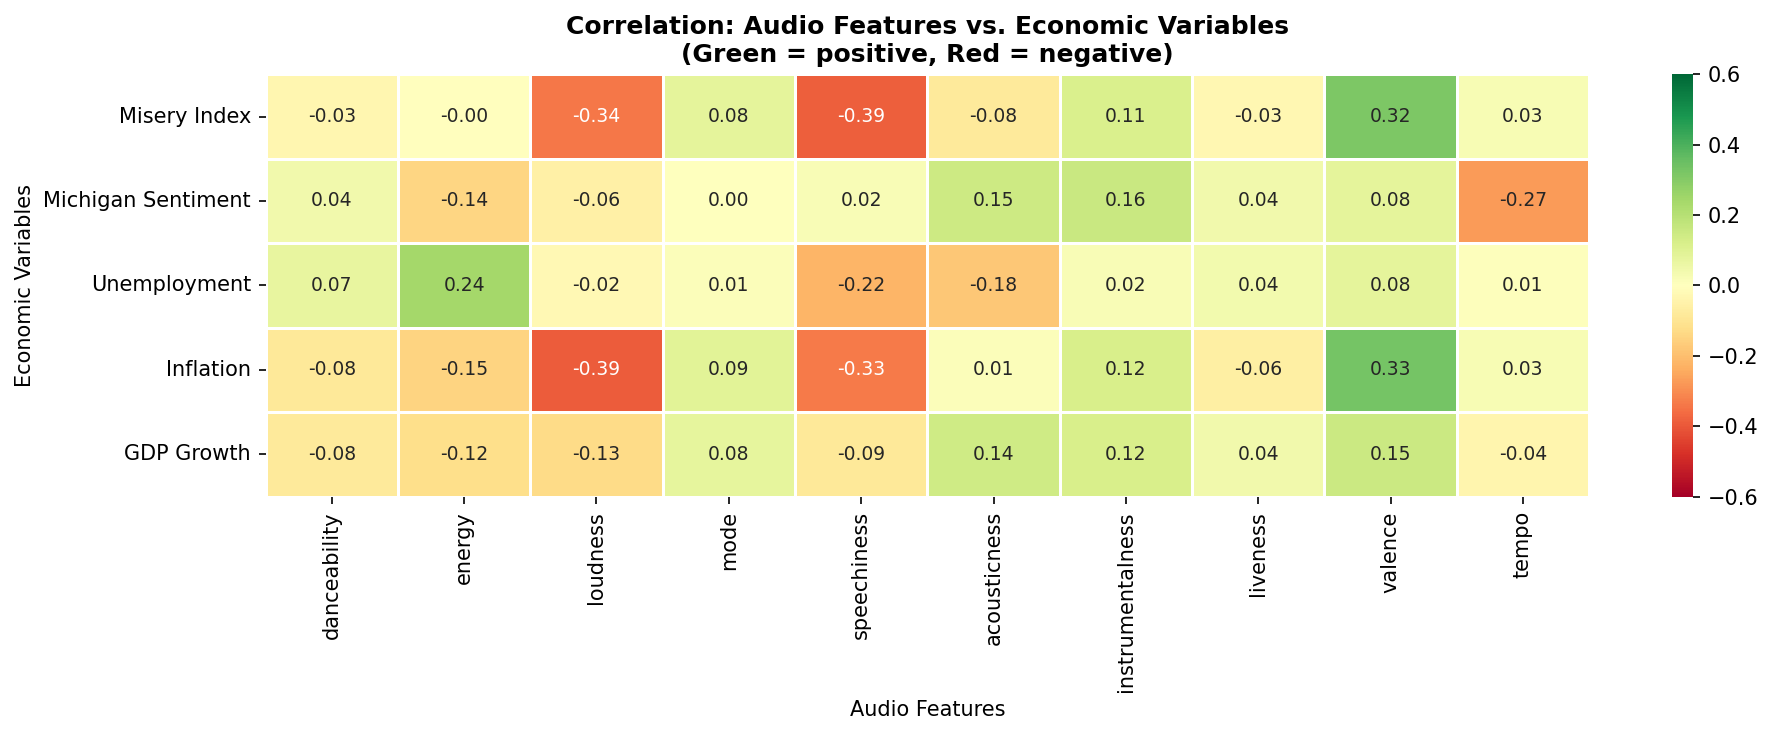

Saved: correlation_heatmap.png

Key correlations (misery index vs. sentiment):
                    valence  loudness  speechiness  instrumentalness  tempo
misery_index          0.317    -0.340       -0.389             0.113  0.026
michigan_sentiment    0.083    -0.057        0.019             0.158 -0.274
unemployment          0.083    -0.024       -0.221             0.022  0.006
inflation             0.330    -0.393       -0.333             0.122  0.028


In [29]:
# ── CORRELATION HEATMAP ───────────────────────────────────────────────────────
AUDIO_FEATURES = [
    'danceability', 'energy', 'loudness', 'mode', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo'
]
ECON_VARS = ['misery_index', 'michigan_sentiment', 'unemployment', 'inflation', 'gdp_growth']

# Use sentiment dataset (has both misery and sentiment)
corr_data = sent_clean[AUDIO_FEATURES + ECON_VARS].dropna()

# Compute correlation matrix (audio features x economic variables only)
corr_matrix = corr_data[AUDIO_FEATURES].corrwith(
    corr_data[ECON_VARS]
).T  # shape: econ_vars x audio_features

# Manually compute full correlation matrix
full_corr = corr_data.corr()
heat_data = full_corr.loc[ECON_VARS, AUDIO_FEATURES]

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(
    heat_data,
    annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, vmin=-0.6, vmax=0.6,
    linewidths=0.5, ax=ax,
    annot_kws={'size': 9}
)
ax.set_title(
    'Correlation: Audio Features vs. Economic Variables\n'
    '(Green = positive, Red = negative)',
    fontsize=12, fontweight='bold'
)
ax.set_xlabel('Audio Features', fontsize=10)
ax.set_ylabel('Economic Variables', fontsize=10)
ax.set_yticklabels([
    'Misery Index', 'Michigan Sentiment',
    'Unemployment', 'Inflation', 'GDP Growth'
], rotation=0)

plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: correlation_heatmap.png')
print('\nKey correlations (misery index vs. sentiment):')
print(heat_data.loc[
    ['misery_index', 'michigan_sentiment', 'unemployment', 'inflation'],
    ['valence', 'loudness', 'speechiness', 'instrumentalness', 'tempo']
].round(3))

## Short Summary


The heatmap reveals that economic conditions leave a measurable but selective imprint on the sonic character of popular music.

On the positive side, **valence** is the strongest and most consistent signal — correlating 0.32 with the Misery Index and 0.33 with inflation — confirming Larson (2022)'s finding that people gravitate toward happier-sounding music during economic hardship. **Instrumentalness** shows a mild but consistent positive relationship across indicators, suggesting a secondary preference for melodic, vocal-light music during stressed periods.

On the negative side, **loudness** (-0.34 with Misery Index, -0.39 with inflation) and **speechiness** (-0.39 with Misery Index, -0.33 with inflation, -0.22 with unemployment) are the clearest inverse signals — loud, vocal-heavy music is associated with more prosperous conditions, while quieter and less speech-driven tracks dominate during downturns.

**Tempo** stands apart as the feature most responsive to *perceived* economic conditions rather than hard data, with its strongest correlation against Michigan Sentiment (-0.27) rather than the Misery Index (0.03). This early distinction between sentiment-driven and data-driven musical responses is the central question carried forward into the regression models in Notebook 3.

Notably, **danceability** and **energy** — the features most associated with the cultural narrative of recession pop — show near-zero correlations across all indicators at the monthly average level, suggesting the relationship may be non-linear, lagged, or genre-specific rather than a broad population-wide trend.

---
## Chart 4 — Feature Trends Over 60 Years
**How have all 11 audio features evolved since 1958?**

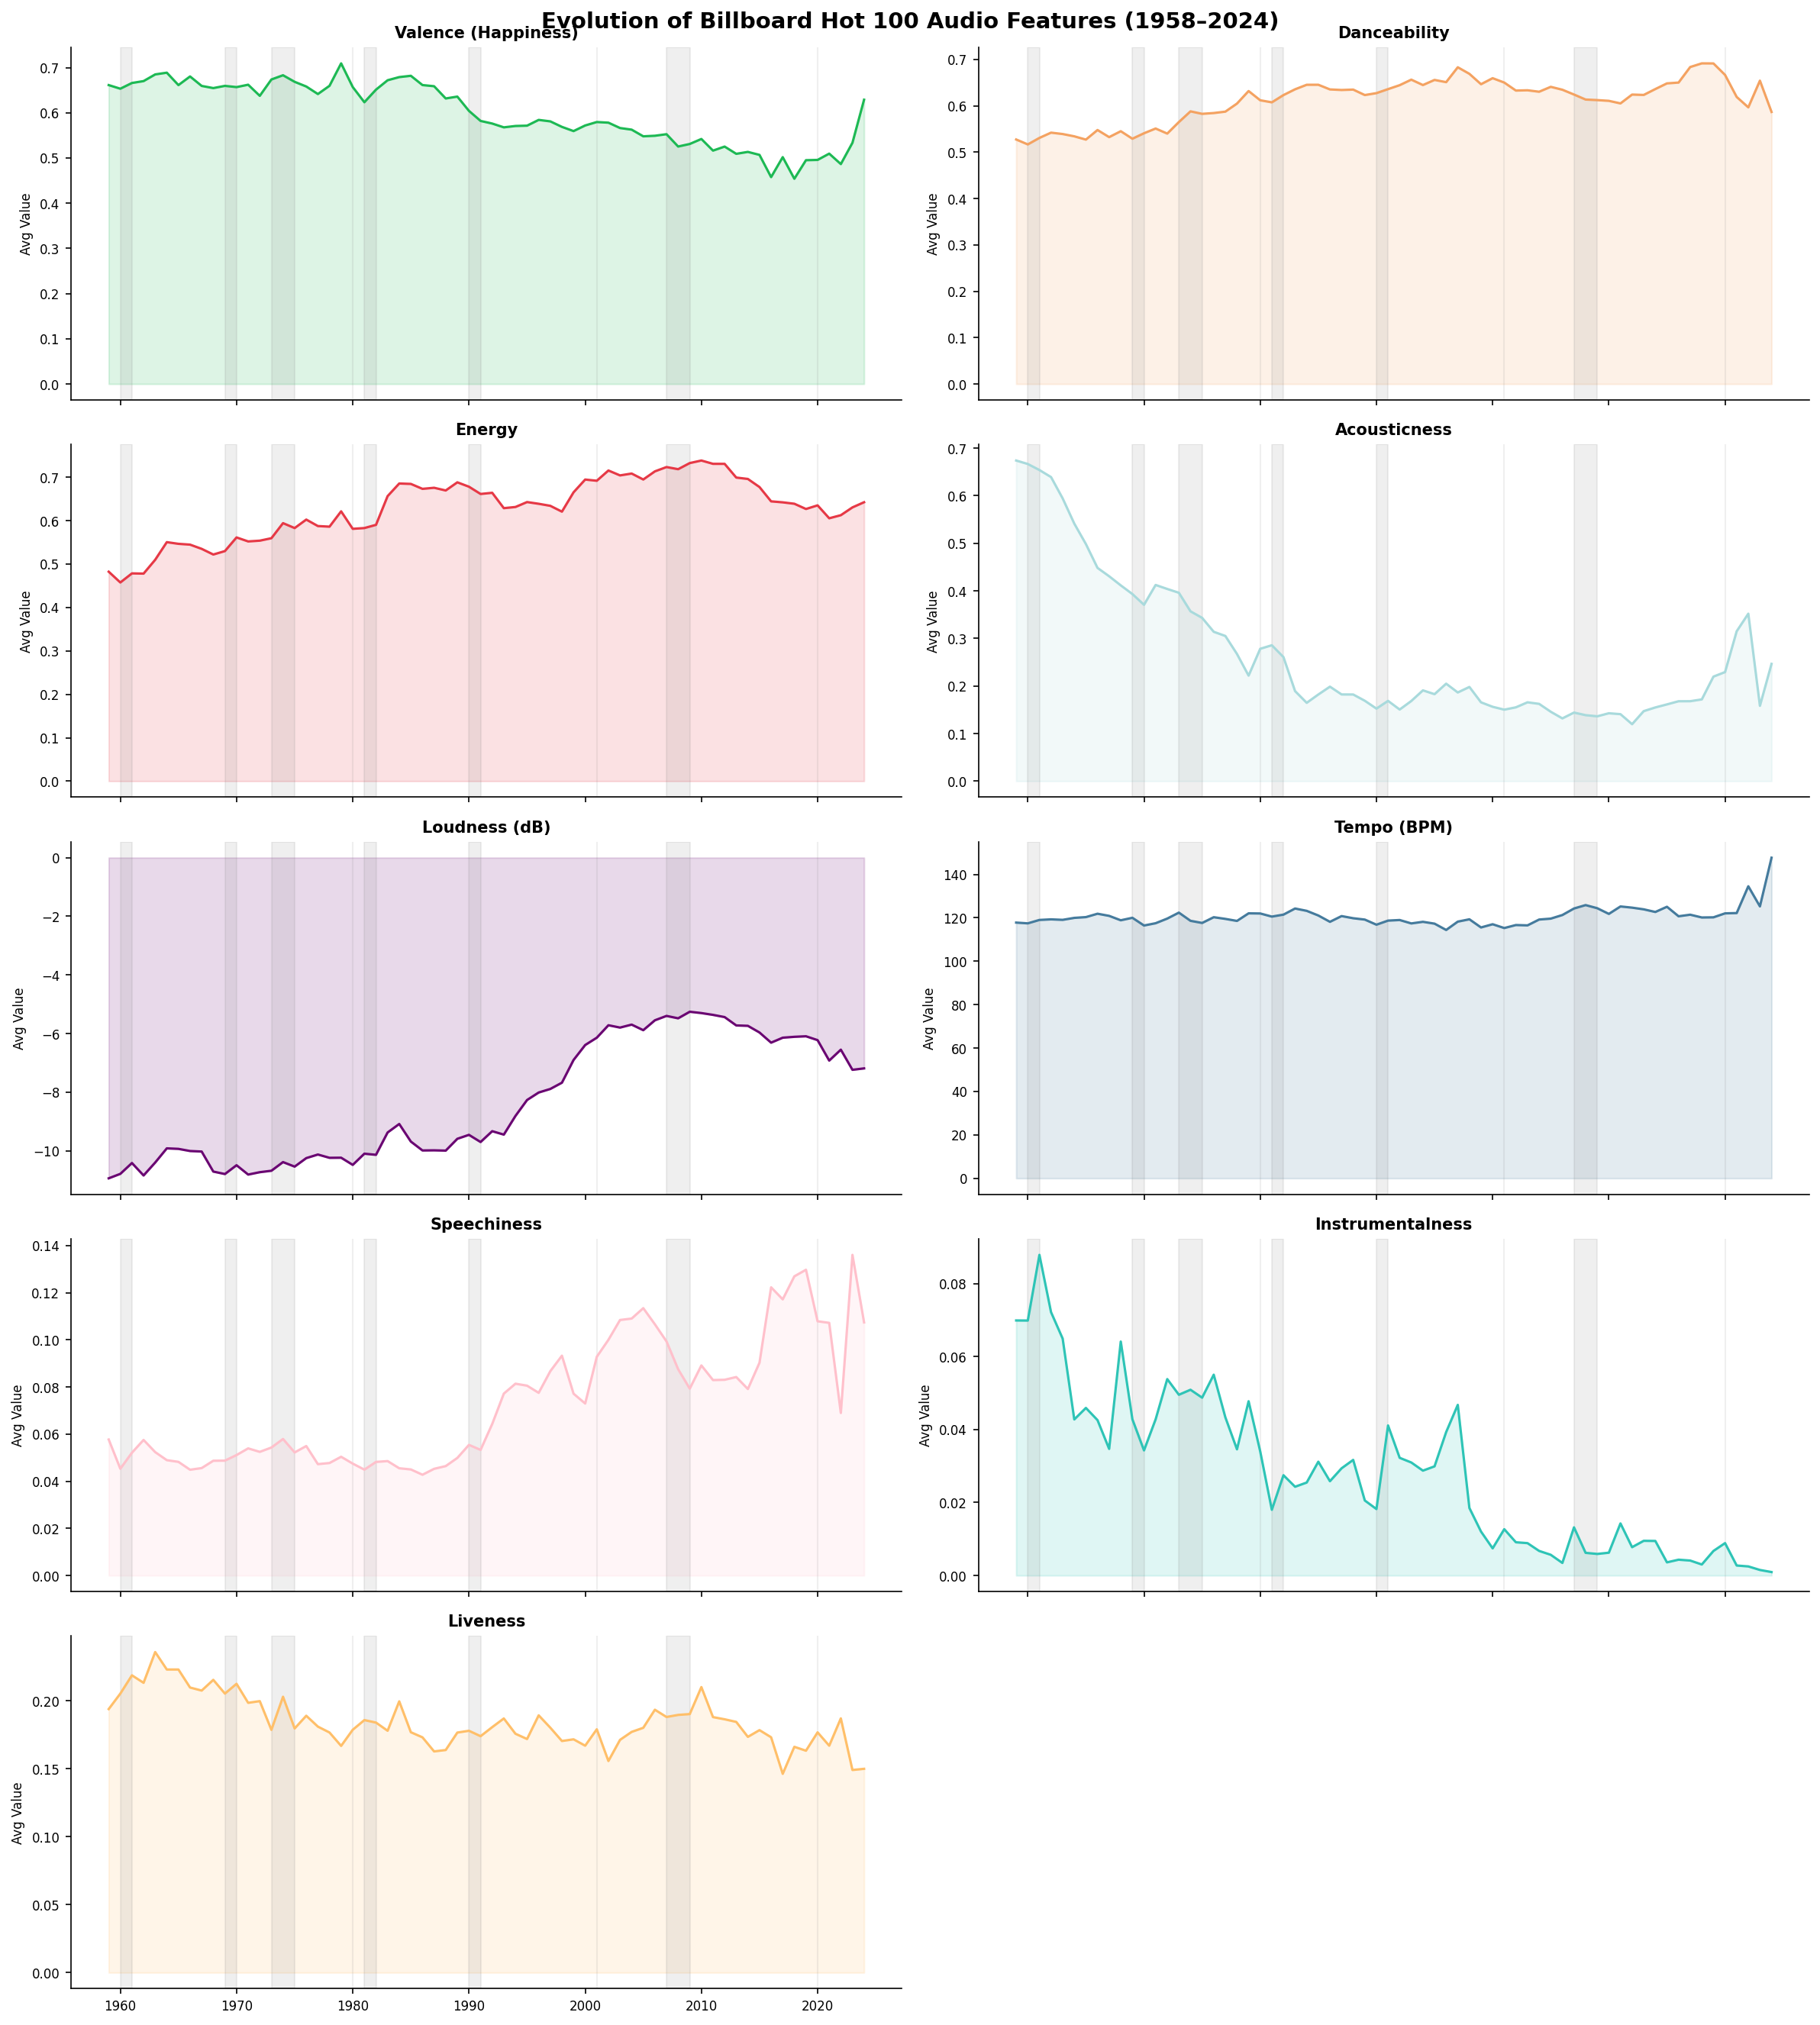

Saved: feature_trends.png


In [30]:
# ── ALL FEATURE TRENDS ────────────────────────────────────────────────────────
FEATURES_PLOT = [
    ('valence',          '#1DB954', 'Valence (Happiness)'),
    ('danceability',     '#F4A261', 'Danceability'),
    ('energy',           '#E63946', 'Energy'),
    ('acousticness',     '#A8DADC', 'Acousticness'),
    ('loudness',         '#6A0572', 'Loudness (dB)'),
    ('tempo',            '#457B9D', 'Tempo (BPM)'),
    ('speechiness',      '#FFC0CB', 'Speechiness'),
    ('instrumentalness', '#2EC4B6', 'Instrumentalness'),
    ('liveness',         '#FFBF69', 'Liveness'),
    ('mode',             '#CBF3F0', 'Mode (Major=1)'),
]

fig, axes = plt.subplots(5, 2, figsize=(16, 18), sharex=True)
fig.suptitle('Evolution of Billboard Hot 100 Audio Features (1958–2024)',
             fontsize=14, fontweight='bold')
axes_flat = axes.flatten()

for i, (feat, color, label) in enumerate(FEATURES_PLOT):
    ax = axes_flat[i]
    # Yearly average for cleaner trend
    yearly = full_clean.groupby('year')[feat].mean()
    ax.plot(yearly.index, yearly.values, color=color, linewidth=1.5)
    ax.fill_between(yearly.index, yearly.values, alpha=0.15, color=color)
    # Add recession shading (using year spans)
    for start, end in RECESSIONS:
        s = pd.to_datetime(start).year
        e = pd.to_datetime(end).year
        ax.axvspan(s, e, alpha=0.12, color='grey')
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_ylabel('Avg Value', fontsize=8)
    ax.tick_params(labelsize=8)

axes_flat[-1].set_visible(False)  # hide last empty subplot
plt.tight_layout()
plt.savefig('feature_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: feature_trends.png')

---
## Chart 5 — Misery Index vs. Sentiment: Who Tracks Music Better?

***Does musical happiness move more closely with how bad the economy is, or with how bad people think it is?***

This chart presents two side-by-side scatter plots, each plotting monthly average valence against one economic variable — the Okun Misery Index on the left and Michigan Consumer Sentiment on the right. Each point represents one month in the dataset. The dashed regression line shows the direction and strength of the linear relationship, and the R² value quantifies how much of the variation in valence is explained by each variable independently.

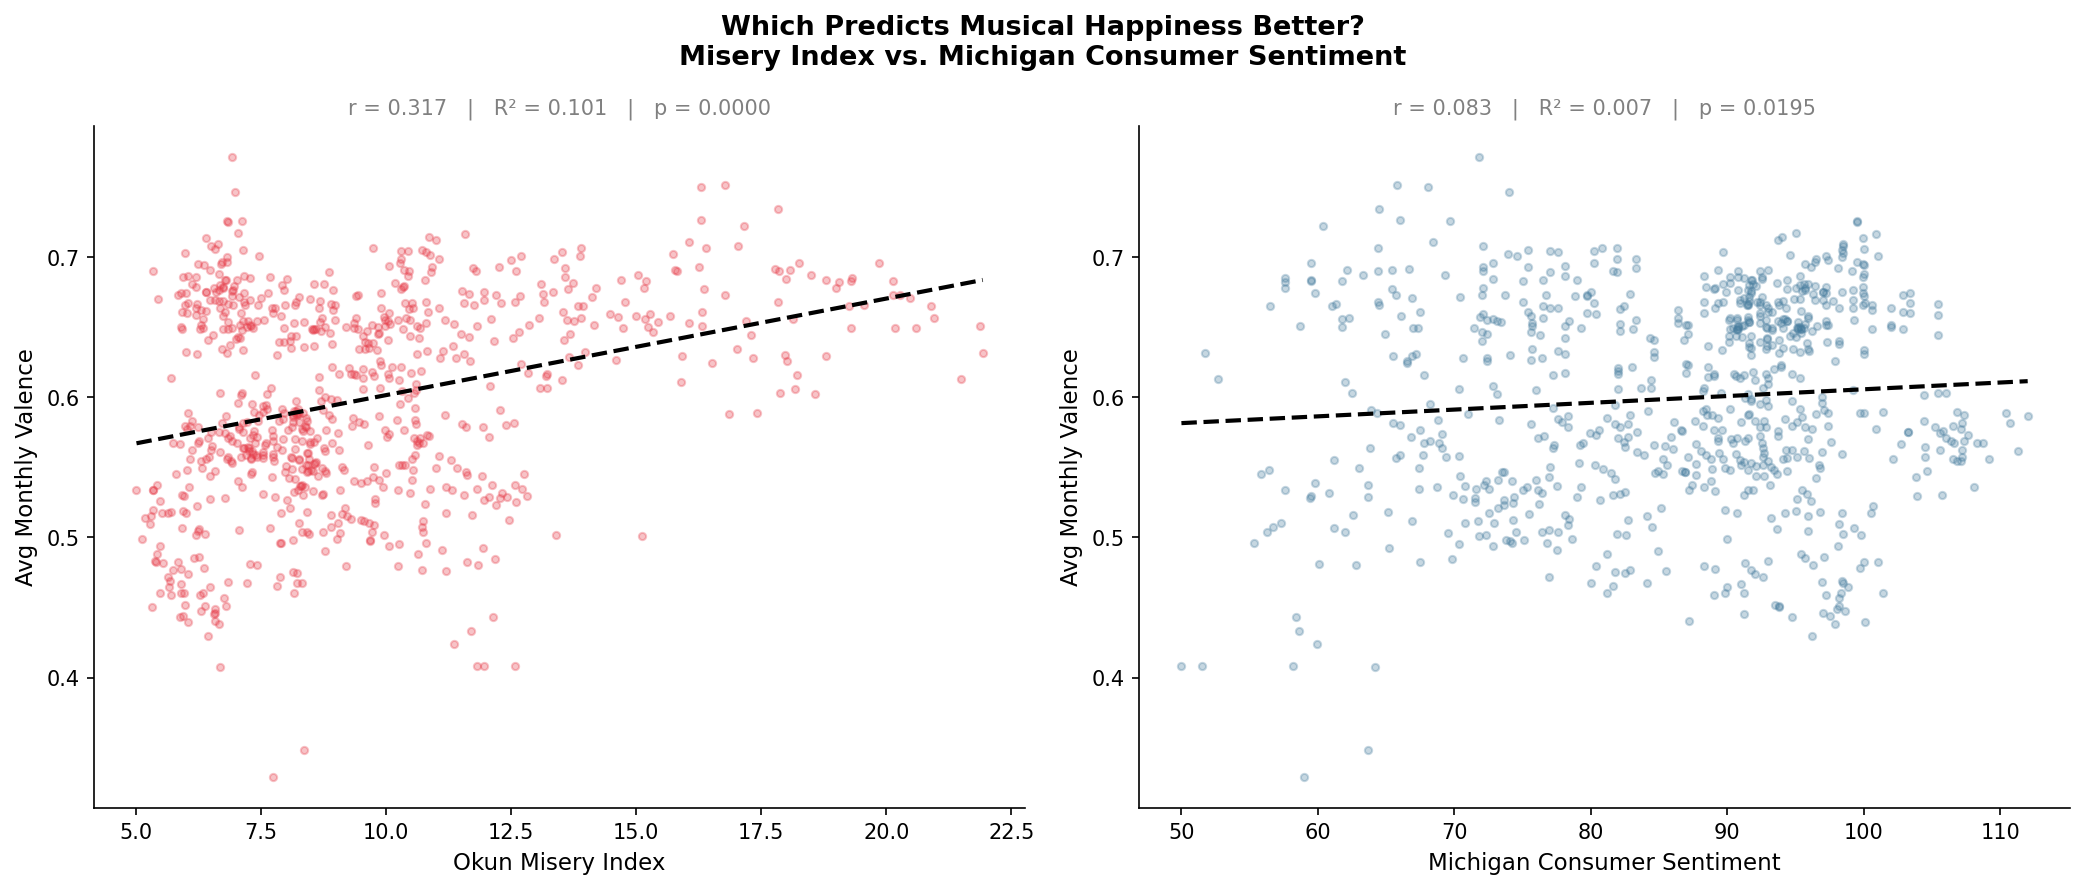

Saved: scatter_misery_vs_sentiment.png

The model with higher R² is the better predictor of musical valence.
This is the visual preview of your regression results in Notebook 3.


In [28]:
# ── SCATTER: Misery vs Sentiment — who predicts valence better? ───────────────
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    'Which Predicts Musical Happiness Better?\nMisery Index vs. Michigan Consumer Sentiment',
    fontsize=13, fontweight='bold'
)

plot_data = sent_clean.dropna(subset=['misery_index', 'michigan_sentiment', 'valence'])

for ax, x_col, x_label, color in [
    (axes[0], 'misery_index',       'Okun Misery Index',              '#E63946'),
    (axes[1], 'michigan_sentiment', 'Michigan Consumer Sentiment',    '#457B9D'),
]:
    x = plot_data[x_col]
    y = plot_data['valence']

    # Scatter
    ax.scatter(x, y, alpha=0.3, s=12, color=color)

    # Regression line
    slope, intercept, r, p, _ = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, slope * x_line + intercept,
            color='black', linewidth=2, linestyle='--')

    ax.set_xlabel(x_label, fontsize=11)
    ax.set_ylabel('Avg Monthly Valence', fontsize=11)
    ax.set_title(
        f'r = {r:.3f}   |   R² = {r**2:.3f}   |   p = {p:.4f}',
        fontsize=10, color='grey'
    )

plt.tight_layout()
plt.savefig('scatter_misery_vs_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: scatter_misery_vs_sentiment.png')
print('\nThe model with higher R² is the better predictor of musical valence.')
print('This is the visual preview of your regression results in Notebook 3.')

## Short Summary

The two scatter plots reveal an asymmetry in how valence relates to economic conditions. The Misery Index shows a stronger linear association with valence than Michigan Sentiment does, consistent with Larson (2022)'s finding that actual economic hardship — rather than perceived anxiety — is the primary driver of happier-sounding music.

However, neither relationship is particularly tight, as reflected in the modest R² values on both sides. This suggests that valence is influenced by economic conditions but not determined by them alone, and that the relationship likely involves non-linear dynamics, lag effects, or interactions between variables that a simple bivariate scatter cannot capture.

---
## Summary

**Figures produced:**
| File | Description |
|---|---|
| `hero_chart.png` | 60-year timeline — the main shareable figure |
| `recession_pop_validation.png` | Danceability & valence vs. recession bands |
| `correlation_heatmap.png` | Audio features × economic variables |
| `feature_trends.png` | All 10 features over 60 years |
| `scatter_misery_vs_sentiment.png` | Visual preview of regression horse race |

**What to look for:**
- Does valence **rise** during recession periods? (Larson's finding — comfort-seeking)
- Does danceability **spike** during recessions? (recession pop thesis)
- Which scatter plot has a **steeper, tighter** regression line — misery or sentiment?